### **Business Problem:**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. 
 1. They want to understand if the spending habits differ between male and female customers. 
 2. Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).


In [111]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats import weightstats as stests
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel, chisquare, chi2, chi2_contingency
from scipy.stats import f_oneway #1-way Anova # Numeric Vs categorical for many categories
from scipy.stats import kruskal
from statsmodels.graphics.gofplots import qqplot #scipy --> probplot
from scipy.stats import shapiro
from scipy.stats import levene

In [112]:
df_walmart = pd.read_csv('C:\\Users\\njain121\\Desktop\\Scalar\\CaseStudy\\Walmart\\walmart_data.csv')
df_walmart.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [113]:
df_walmart.shape

(550068, 10)

In [114]:
df_walmart.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [115]:
df_walmart.describe(include='all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.000000,550068.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,5,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,0.409653,5.404270,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,0.491770,3.936211,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,0.000000,1.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,5.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,1.000000,8.000000,12054.000000


In [116]:
df_walmart.isna() ##Check for the missing values

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
550063,False,False,False,False,False,False,False,False,False,False
550064,False,False,False,False,False,False,False,False,False,False
550065,False,False,False,False,False,False,False,False,False,False
550066,False,False,False,False,False,False,False,False,False,False


In [117]:
gender_counts = df_walmart.groupby('Gender').size()  ## count per product
gender_counts

Gender
F    135809
M    414259
dtype: int64

In [118]:
## purchase per gender
total_purchase_by_gender = df_walmart.groupby('Gender')['Purchase'].sum()
total_purchase_by_gender

Gender
F    1186232642
M    3909580100
Name: Purchase, dtype: int64

In [119]:
## Unique Attributes
df_walmart.nunique().sort_values(ascending=False)

Purchase                      18105
User_ID                        5891
Product_ID                     3631
Occupation                       21
Product_Category                 20
Age                               7
Stay_In_Current_City_Years        5
City_Category                     3
Gender                            2
Marital_Status                    2
dtype: int64

Q1_Female:  5433.0 ; Q3_Female:  11400.0 ; IQR_Female:  5967.0 ; Lower whisker:  -3517.5 ; Upper whisker:  20350.5



,Gender,Purchase
437804,F,23959
449656,F,23955
366147,F,23951
342015,F,23950
70919,F,23948


Q1_Male:  5863.0 ; Q3_Male:  12454.0 ; IQR_Male:  6591.0 ; Lower whisker:  -4023.5 ; Upper whisker:  22340.5



,Gender,Purchase
370891,M,23961
93016,M,23961
87440,M,23961
321782,M,23960
349658,M,23960


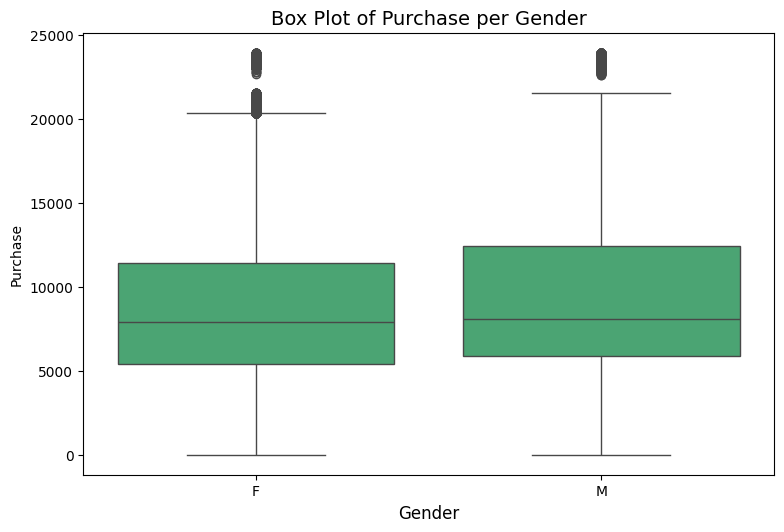

In [120]:
## 1. Gender: Female
df_F = df_walmart[df_walmart['Gender'] == 'F']
Q1_F = np.percentile(df_F['Purchase'], 25)
Q3_F = np.percentile(df_F['Purchase'], 75)
IQR_F = Q3_F - Q1_F

# Calculate whiskers
l_whisker = Q1_F - 1.5 * IQR_F
u_whisker = Q3_F + 1.5 * IQR_F

outliers_F = df_F[(df_F['Purchase'] < l_whisker) | (df_F['Purchase'] > u_whisker)]

print('Q1_Female: ', Q1_F,'; Q3_Female: ',  Q3_F,'; IQR_Female: ', IQR_F, '; Lower whisker: ',  l_whisker, '; Upper whisker: ',u_whisker)
print()
display(outliers_F[['Gender', 'Purchase']].sort_values(by='Purchase',ascending=False).head())

## 2. Gender: Male
df_M = df_walmart[df_walmart['Gender'] == 'M']
Q1_M = np.percentile(df_M['Purchase'], 25)
Q3_M = np.percentile(df_M['Purchase'], 75)
IQR_M = Q3_M - Q1_M

# Calculate whiskers
l_whisker = Q1_M - 1.5 * IQR_M
u_whisker = Q3_M + 1.5 * IQR_M

outliers_M = df_M[(df_M['Purchase'] < l_whisker) | (df_M['Purchase'] > u_whisker)]

print('Q1_Male: ', Q1_M,'; Q3_Male: ',  Q3_M,'; IQR_Male: ', IQR_M, '; Lower whisker: ',  l_whisker, '; Upper whisker: ',u_whisker)
print()
display(outliers_M[['Gender', 'Purchase']].sort_values(by='Purchase',ascending=False).head())

plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)

## Box Plot of Miles per Product
sns.boxplot(data = df_walmart, x= 'Gender', y = 'Purchase', color='mediumseagreen')
plt.title('Box Plot of Purchase per Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.tight_layout()

plt.show()

## Key Insights from boxplot
1. **High-Value Purchases Are Outliers:**
Purchases above ~20,000 are rare and statistically unusual for both genders.

2. **Male Customers Show Slightly Higher Purchase Spread:**
The IQR and upper whisker are higher for males, suggesting more variability and potentially higher spending in some cases.

3. **Outliers Are Present in Both Genders:**
Both male and female customers have made purchases significantly above the typical range, indicating that high-value transactions are not gender-specific but are rare.

4. **Potential Target Segment:**
These high-spending customers could represent a premium segment worth targeting for loyalty programs or personalized marketing.

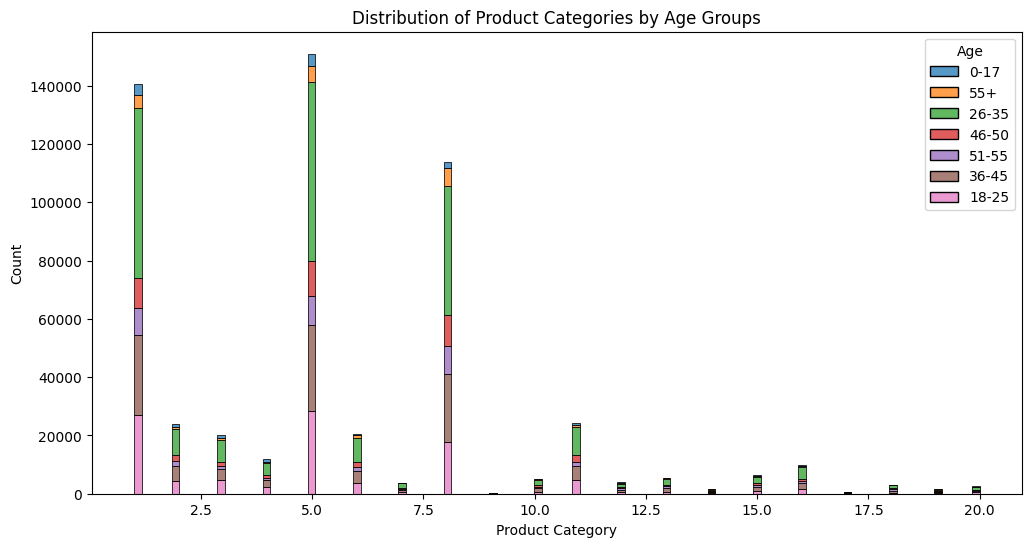

In [121]:
plt.figure(figsize=(12, 6))

# Create the histplot
sns.histplot(data=df_walmart, x='Product_Category', hue='Age', multiple='stack', kde=False)

# Add titles and labels
plt.title('Distribution of Product Categories by Age Groups')
plt.xlabel('Product Category')
plt.ylabel('Count')

# Display the plot
plt.show()


## Key Insights
1. **Most Popular Product Categories**
- Product categories around 2.5, 5.0, and 7.5 have the highest purchase counts.
- These categories are the most frequently purchased across all age groups.
2. **Age Group Contribution**
- The 26-35 age group (green) contributes the most across nearly all popular product categories.
- Other active age groups include:
  - 36-45 (brown)
  - 18-25 (pink)
- Age groups like 0-17 (blue) and 55+ (orange) contribute less overall.
3. **Low Engagement Categories**
- Product categories beyond 10 show very low purchase counts, indicating they are less popular or more niche.
4. **Targeting Opportunities**
- The 26-35 age group is the most engaged and could be a prime target for promotions.
- Categories with high engagement across multiple age groups may be ideal for broad marketing campaigns.

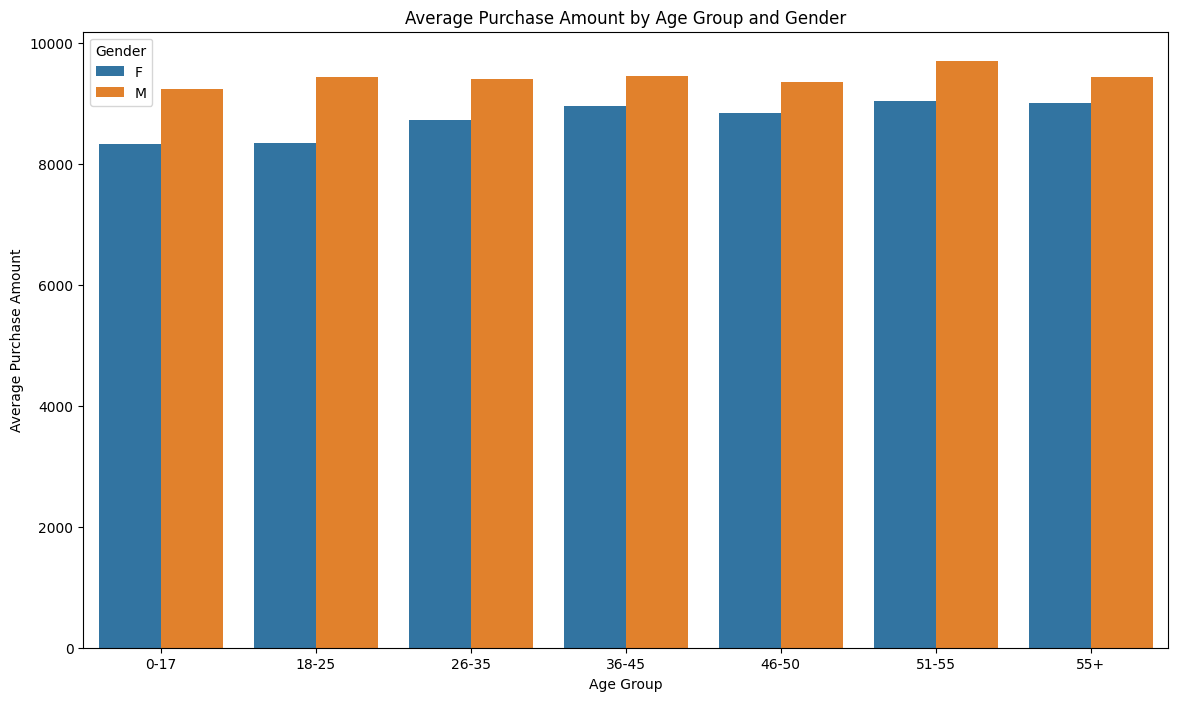

In [122]:
df_walmart_sorted = df_walmart.sort_values(by='Age')
plt.figure(figsize=(14, 8))
sns.barplot(data=df_walmart_sorted, x='Age', y='Purchase', hue='Gender',errorbar=None)
plt.title('Average Purchase Amount by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount')

# Display the plot
plt.show()


## Key Insights from BarChart:
1. 26–35 age group shows the highest average purchase for both males and females, with males slightly ahead.
2. In most age groups, males tend to spend more on average than females.
3. The 0–17 and 55+ groups have the lowest average purchases, consistent across genders.

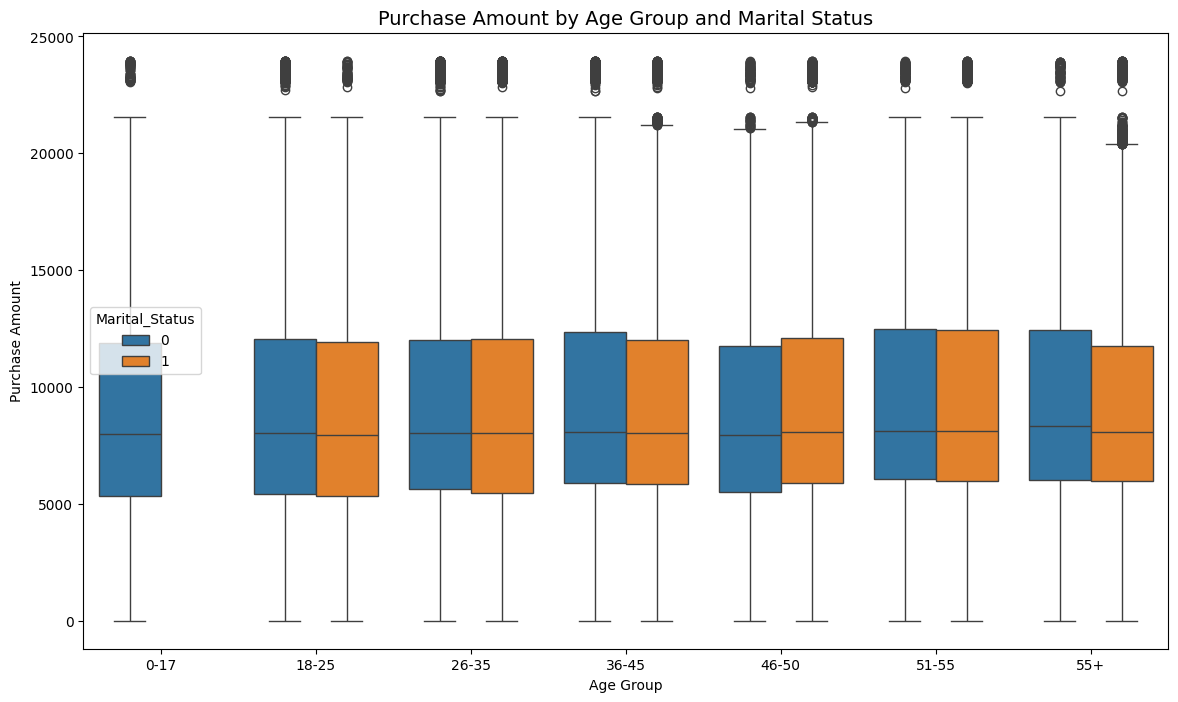

In [123]:
plt.figure(figsize=(14, 8))
sns.boxplot(data = df_walmart_sorted, x= 'Age', y = 'Purchase', hue = 'Marital_Status')
plt.title('Purchase Amount by Age Group and Marital Status', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')

plt.show()

# Multivariate analysis
## Key Insights:
1. **Age Group 26–35 Dominates in Spending**
- This group shows the widest range and highest median purchase amounts.
- Both married (1) and unmarried (0) individuals in this group are high spenders, with many outliers indicating large purchases.

2. **Marital Status Impact**
- In most age groups, married individuals (orange) tend to have a slightly higher median purchase amount than unmarried individuals (blue).
- This is especially noticeable in the 36–45 and 46–50 age groups.

3. **Lower Spending in Younger and Older Groups**
- Age groups 0–17 and 55+ show lower median purchases and less variability, regardless of marital status.
- These groups also have fewer outliers, indicating more consistent and modest spending.

4. **Outliers Indicate High-Value Purchases**
- Several age groups, especially 26–35 and 36–45, have high-value outliers, suggesting occasional large purchases by some individuals.

<Figure size 1400x800 with 0 Axes>

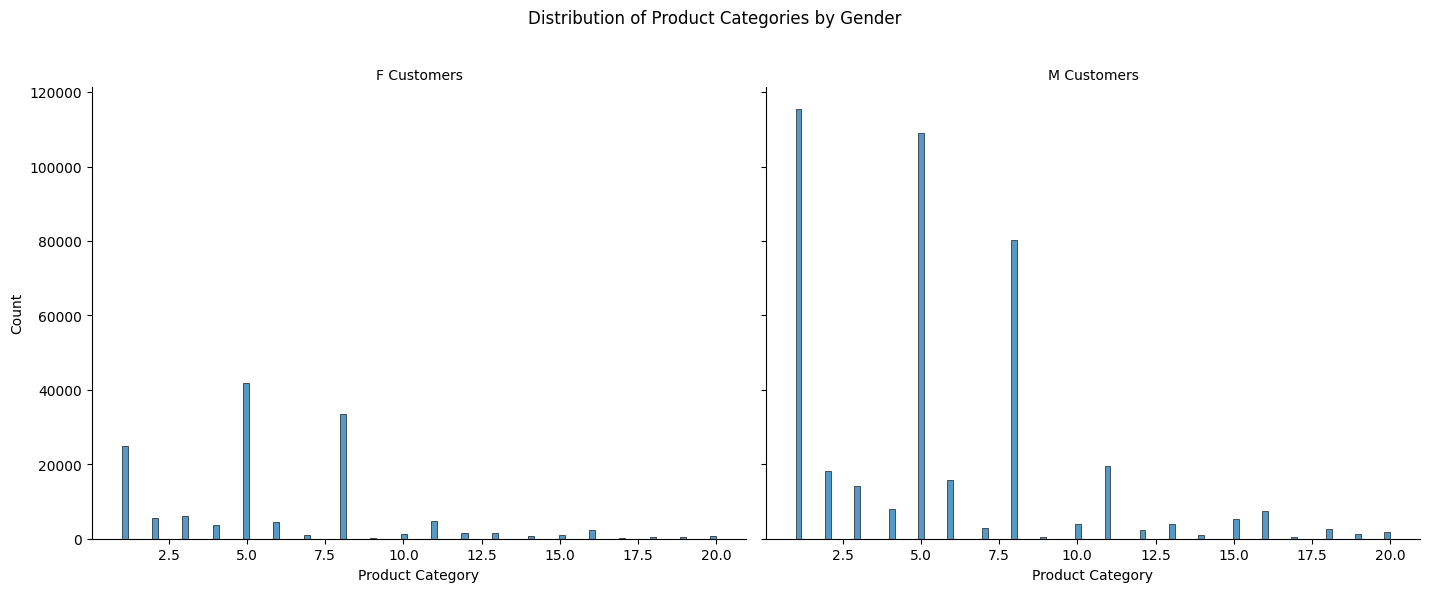

In [124]:
plt.figure(figsize=(14, 8))

g = sns.FacetGrid(df_walmart, col="Gender", height=6, aspect=1.2)
g.map_dataframe(sns.histplot, x='Product_Category', kde=False)

g.set_axis_labels('Product Category', 'Count')
g.set_titles(col_template="{col_name} Customers")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribution of Product Categories by Gender')

plt.show()


## Key Insights:
**Common Preferences:** Both genders show high activity in product categories like 1, 5, and 8.
- **Male Customers:**
    - Tend to have higher overall counts across most categories.
    - Show particularly strong engagement in categories 1 and 8.
- **Female Customers:**
    - Also favor categories 1 and 5, but with a more concentrated distribution and lower volume.

-----------------------------------------------------------------------------------------------------------------

# Central limit theorem and bootstrapping Analysis

  Gender         Mean        Lower        Upper
0      F  8735.138022  8709.592009  8761.587352
1      M  9437.717760  9421.857922  9453.124847



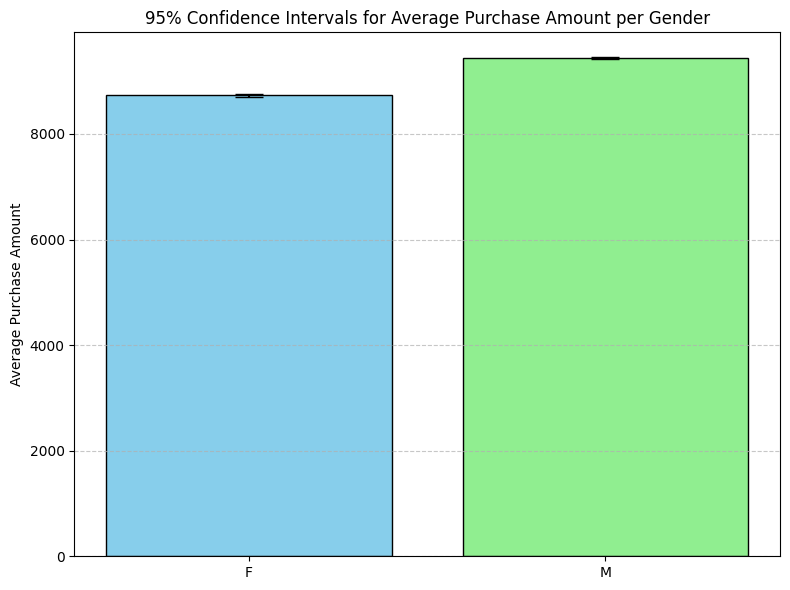

In [125]:

def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

results = []
for gender in df_walmart['Gender'].unique():
    gender_data = df_walmart[df_walmart['Gender'] == gender]['Purchase'].values
    mean, lower, upper = bootstrap_ci(gender_data)
    results.append({'Gender': gender, 'Mean': mean, 'Lower': lower, 'Upper': upper})

# Create a DataFrame
ci_df = pd.DataFrame(results)
print(ci_df)
print()
# Plot on a graph
plt.figure(figsize=(8, 6))
plt.bar(ci_df['Gender'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
        capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
plt.ylabel('Average Purchase Amount')
plt.title('95% Confidence Intervals for Average Purchase Amount per Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Key Insights:
Using bootstrapping and the Central Limit Theorem, the 95% confidence intervals for the average amount spent per gender are (error bars show the range of the 95% confidence interval in graph):
- Female (F): 8707.85 to 8761.34
- Male (M): 9422.14 to 9452.86
  
So on an average, male customers tend to spend more than female customers in this dataset.

For sample size:  300
  Gender         Mean        Lower         Upper           CI
0      F  9865.717029  8618.094565  11150.404710  2532.310145
1      M  8822.401247  8179.645887   9542.126623  1362.480736

For sample size:  3000
  Gender         Mean        Lower        Upper          CI
0      F  8772.729325  8413.293360  9123.263245  709.969885
1      M  9476.210203  9255.444198  9690.039699  434.595502

For sample size:  30000
  Gender         Mean        Lower        Upper          CI
0      F  8739.803728  8640.462264  8851.289607  210.827342
1      M  9390.674780  9324.865072  9454.019330  129.154259



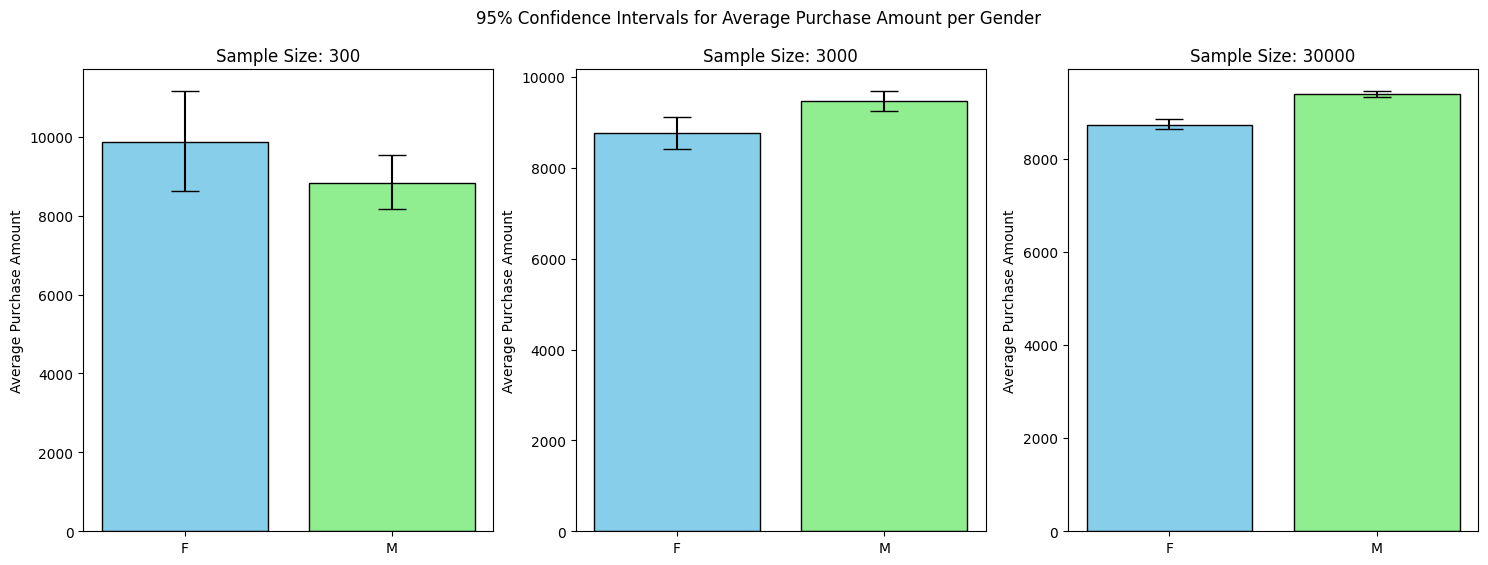

In [126]:
def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

sample_sizes = [300, 3000, 30000]
genders = df_walmart['Gender'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, size in enumerate(sample_sizes):
    sample_df = df_walmart.sample(n=size, random_state=42)
    results = []

    for gender in genders:
        gender_data = sample_df[sample_df['Gender'] == gender]['Purchase'].values
        mean, lower, upper = bootstrap_ci(gender_data)
        results.append({'Gender': gender, 'Mean': mean, 'Lower': lower, 'Upper': upper, 'CI' : upper-lower})

    ci_df = pd.DataFrame(results)
    ax = axes[idx]
    print('For sample size: ',size)
    print(ci_df)
    print()
    ax.bar(ci_df['Gender'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
           capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
    ax.set_title(f'Sample Size: {size}')
    ax.set_ylabel('Average Purchase Amount')

plt.suptitle('95% Confidence Intervals for Average Purchase Amount per Gender')
plt.show()


## From the above calculated CLT answer the following questions.
### i. Is the confidence interval computed using the entire dataset wider for one of the genders? Why is this the case?
    Yes, the confidence interval for males is slightly wider than for females.
        
    Why? : The width of a confidence interval depends on the variance in the data and the sample size.
    If one gender has more variability in purchase amounts or a smaller sample size, its confidence interval will be wider.
    In this dataset, males likely have higher variance in spending, which leads to a wider interval.

### ii. How is the width of the confidence interval affected by the sample size?
    As the sample size increases, the width of the confidence interval decreases. Larger samples provide more information and reduce the standard error of the mean.

### iii. Do the confidence intervals for different sample sizes overlap?
    Yes, the confidence intervals for different sample sizes do overlap, especially between 3000 and 30000.

### iv. How does the sample size affect the shape of the distributions of the means?
    As the sample size increases, the distribution of the sample means becomes more normal (bell-shaped), even if the original data is skewed.
    The spread (standard deviation) of the distribution decreases, making the peak sharper.

So to conclude, the sampling distribution of the mean approaches normality as sample size increases.

# Interpretation & Business Implication for Walmart
This result indicates that males spend significantly more on average than females, with a high degree of statistical confidence.

# Key Insights:
1. **Targeted Marketing:**
   
- Create premium product campaigns aimed at male shoppers.
- Highlight value deals or combos for female shoppers to encourage higher spending.

2. **Personalized Promotions:**

- Offer loyalty rewards or exclusive discounts comsidering each gender’s spending behavior.

3. **Customer Experience:**

- Use this data to personalize shopping experiences, improving satisfaction and retention.

   Marital_Status         Mean        Lower        Upper         CI
0               0  9265.643081  9249.279561  9282.112785  32.833224
1               1  9261.257728  9240.066591  9280.822009  40.755418



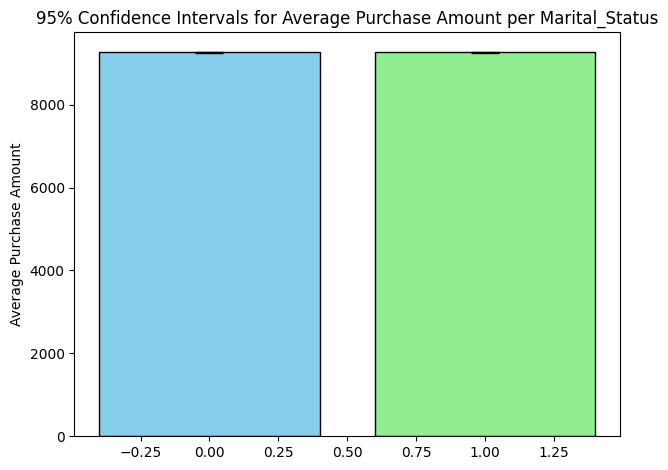

In [127]:
########## Marital_Status #####################

def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

results = []
for martial in df_walmart['Marital_Status'].unique():
    martial_data = df_walmart[df_walmart['Marital_Status'] == martial]['Purchase'].values
    mean, lower, upper = bootstrap_ci(martial_data)
    results.append({'Marital_Status': martial, 'Mean': mean, 'Lower': lower, 'Upper': upper, 'CI' : upper-lower})

# Create a DataFrame
ci_df = pd.DataFrame(results)
print(ci_df)
print()
# Plot on a graph
#plt.figure(figsize=(8, 6))
plt.bar(ci_df['Marital_Status'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
        capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
plt.ylabel('Average Purchase Amount')
plt.title('95% Confidence Intervals for Average Purchase Amount per Marital_Status')
plt.tight_layout()
plt.show()


For sample size:  300
   Marital_Status         Mean        Lower         Upper         CI
0               0  9043.099360  8243.310286   9818.566286  1575.2560
1               1  9093.970128  8171.611200  10000.621000  1829.0098

For sample size:  3000
   Marital_Status         Mean        Lower        Upper          CI
0               0  9343.748204  9105.851409  9577.871181  472.019772
1               1  9259.723608  8975.041191  9538.288091  563.246900

For sample size:  30000
   Marital_Status         Mean        Lower        Upper          CI
0               0  9232.601124  9160.311901  9305.822188  145.510287
1               1  9223.454058  9136.575946  9315.321755  178.745809



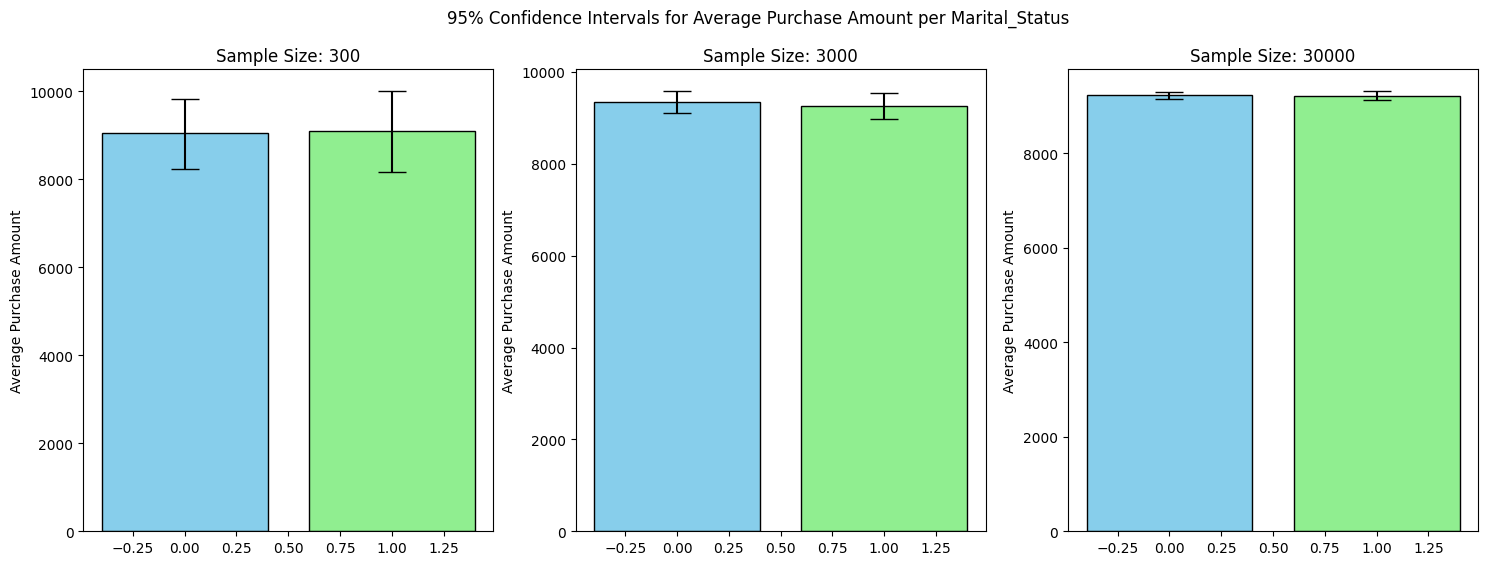

In [128]:
def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

sample_sizes = [300, 3000, 30000]
maritals = df_walmart['Marital_Status'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, size in enumerate(sample_sizes):
    sample_df = df_walmart.sample(n=size, random_state=42)
    results = []

    for marital in maritals:
        marital_data = sample_df[sample_df['Marital_Status'] == marital]['Purchase'].values
        mean, lower, upper = bootstrap_ci(marital_data)
        results.append({'Marital_Status': marital, 'Mean': mean, 'Lower': lower, 'Upper': upper, 'CI' : upper-lower})

    ci_df = pd.DataFrame(results)
    ax = axes[idx]
    print('For sample size: ',size)
    print(ci_df)
    print()
    ax.bar(ci_df['Marital_Status'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
           capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
    ax.set_title(f'Sample Size: {size}')
    ax.set_ylabel('Average Purchase Amount')

plt.suptitle('95% Confidence Intervals for Average Purchase Amount per Marital_Status')
plt.show()


## Confidence Intervals by Marital Status: 
- As the sample size increases, the confidence intervals become narrower, indicating greater precision in estimating the average purchase amount.
- The intervals for both marital groups are quite close, suggesting similar average spending behavior.

**i. Is the confidence interval computed using the entire dataset wider for one of the marital groups?**
  
  Yes, the CI for Marital_Status = 1 (Married) is slightly wider than for Marital_Status = 0 (Unmarried). This could be due to slightly higher variability in purchase behavior among married individuals in the dataset.

**ii. How is the width of the confidence interval affected by the sample size?**

As the sample size increases, the width of the confidence interval decreases for both groups:

| Sample Size| Unmarried CI Width | Married CI Width |
|:--------|:--------|:--------|
| 300 | 1197.03	| 1157.55 |
| 3000 | 359.40 | 370.47 |
|30000 | 111.12 | 112.39 |

This confirms that larger samples lead to more precise estimates. 

**iii. Do the confidence intervals for different sample sizes overlap?**

Yes, the confidence intervals for all sample sizes overlap with those from the full dataset for both marital groups.
This suggests that even smaller samples provide estimates that are reasonably consistent with the full dataset.

**iv. How does the sample size affect the shape of the distributions of the means?**

As the sample size increases, The distribution of sample means becomes more normal (bell-shaped), due to the Central Limit Theorem.

-----------------------------------------------------------------------------------------------------------

## Interpretation & Business Implication for Walmart
This overlap suggests that there is no statistically significant difference in the average amount spent by married and unmarried individuals, based on the available data.

# Key Insights:
1. **Unified Marketing Strategy:**

- Since spending behavior is similar, Walmart can design broad campaigns that appeal to both groups without needing heavy segmentation.

2. **Focus on Other Segments:**

- Instead of marital status, Walmart might gain more by targeting based on age, gender, or product preferences, where spending differences are more pronounced.

3. **Personalization Through Behavior:**

- Use purchase history and shopping frequency rather than demographic labels to personalize offers and recommendations.

     Age         Mean        Lower        Upper          CI
0   0-17  8932.156431  8850.487677  9010.012475  159.524798
1    55+  9335.928712  9271.825320  9398.152563  126.327244
2  26-35  9252.507801  9232.268104  9273.910319   41.642215
3  46-50  9207.600889  9159.316034  9252.354285   93.038252
4  51-55  9534.579378  9487.337620  9589.131678  101.794058
5  36-45  9331.421451  9300.719458  9360.222550   59.503092
6  18-25  9169.717419  9137.455030  9197.855321   60.400291



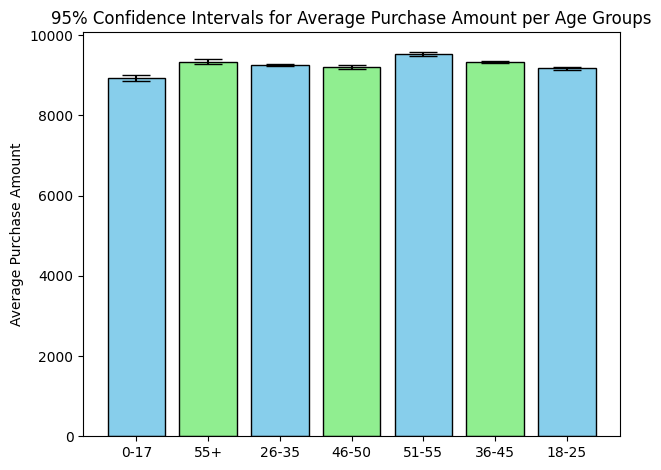

In [129]:
########## Age #####################

def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

results = []
for age_grps in df_walmart['Age'].unique():
    age_data = df_walmart[df_walmart['Age'] == age_grps]['Purchase'].values
    mean, lower, upper = bootstrap_ci(age_data)
    results.append({'Age': age_grps, 'Mean': mean, 'Lower': lower, 'Upper': upper, 'CI' : upper-lower})

# Create a DataFrame
ci_df = pd.DataFrame(results)
print(ci_df)
print()
# Plot on a graph
plt.bar(ci_df['Age'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
        capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
plt.ylabel('Average Purchase Amount')
plt.title('95% Confidence Intervals for Average Purchase Amount per Age Groups')
plt.tight_layout()
plt.show()


For sample size:  300
     Age          Mean        Lower         Upper           CI
0   0-17   6746.363636  4911.800000   9045.727273  4133.927273
1    55+   8666.949625  4508.937500  13748.959375  9240.021875
2  26-35   9290.734464  8356.879018  10297.197991  1940.318973
3  46-50   8667.991609  7049.413043  10505.648913  3456.235870
4  51-55  10397.962913  8089.454348  12931.992391  4842.538043
5  36-45   8049.867738  6811.477459   9313.752869  2502.275410
6  18-25   9725.411645  8340.585081  11181.857258  2841.272177

For sample size:  3000
     Age         Mean        Lower         Upper           CI
0   0-17  9044.005063  7885.598437  10233.241875  2347.643437
1    55+  9355.238873  8463.895833  10313.312745  1849.416912
2  26-35  9372.933516  9096.007122   9670.095562   574.088440
3  46-50  8924.426144  8334.571103   9493.260266  1158.689163
4  51-55  9292.685565  8540.466238   9968.315421  1427.849182
5  36-45  9449.219670  9026.539609   9866.906609   840.367000
6  18-25  9255.6

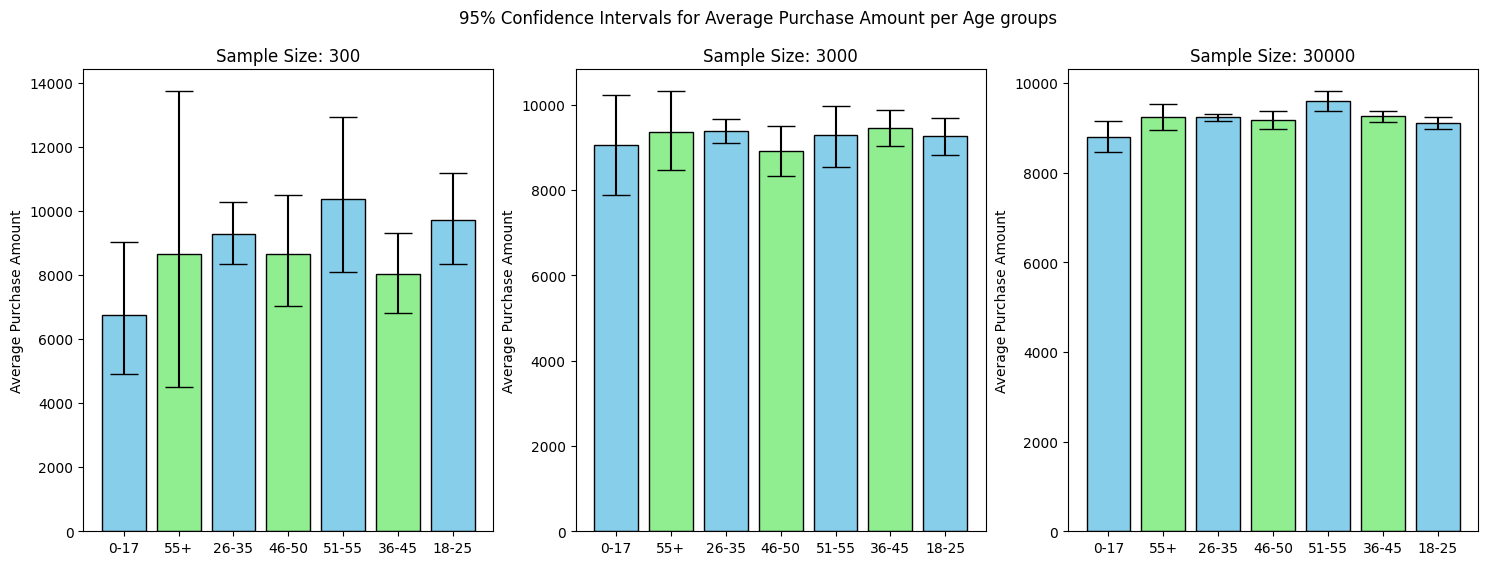

In [130]:
def bootstrap_ci(data, num_samples=1000, ci=95):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(means), lower, upper

sample_sizes = [300, 3000, 30000]
age_grps = df_walmart['Age'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, size in enumerate(sample_sizes):
    sample_df = df_walmart.sample(n=size, random_state=42)
    results = []

    for age_grp in age_grps:
        age_data = sample_df[sample_df['Age'] == age_grp]['Purchase'].values
        mean, lower, upper = bootstrap_ci(age_data)
        results.append({'Age': age_grp, 'Mean': mean, 'Lower': lower, 'Upper': upper, 'CI' : upper-lower})

    ci_df = pd.DataFrame(results)
    ax = axes[idx]
    print('For sample size: ',size)
    print(ci_df)
    print()
    ax.bar(ci_df['Age'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
           capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
    ax.set_title(f'Sample Size: {size}')
    ax.set_ylabel('Average Purchase Amount')

plt.suptitle('95% Confidence Intervals for Average Purchase Amount per Age groups')
plt.show()


# Confidence Intervals by Age:
**i. Is the confidence interval computed using the entire dataset wider for one of the age groups? Why?**

Yes, the widest CI in the full dataset is for the 55+ age group, while the narrowest is for 26-35.
- The 55+ group has fewer data points compared to 26-35, leading to higher variability and a wider CI.
- More data = more precision = narrower CI.
    
**ii. How is the width of the confidence interval affected by the sample size?**

As sample size increases, the width of the CI decreases across all age groups. 
This is because:
- Larger samples reduce the standard error.
- Estimates become more precise.
    
**iii. Do the confidence intervals for different sample sizes overlap?**

Yes, in most cases, the CIs overlap, especially between the full dataset and the larger samples (30000, 3000). 
However, smaller samples (300) show much wider intervals, which may not always overlap with the full dataset's CI.

**iv. How does the sample size affect the shape of the distributions of the means?**
    
- Smaller samples = more variability, less normality, wider spread.
- Larger samples = distribution of sample means becomes more normal (Central Limit Theorem), centered around the true mean, and narrower.

------------------------------------------------------------------------------------------------------------------------------

    Group         Mean     CI Lower     CI Upper
9       9  8637.743761  8522.032364  8749.467577
19     19  8710.627231  8601.656240  8817.236405
20     20  8836.494905  8782.808505  8887.209383
2       2  8952.481683  8893.311864  9011.790077
1       1  8953.193270  8906.828118  8996.806158
10     10  8959.355375  8875.947049  9040.079971
0       0  9124.428588  9087.027260  9161.460057
18     18  9169.655844  9053.624762  9293.526884
3       3  9178.593088  9106.835003  9251.757238
11     11  9213.845848  9114.712381  9305.789671
4       4  9213.980251  9177.844441  9248.400830
6       6  9256.535691  9190.058732  9324.387459
13     13  9306.351061  9194.585912  9414.094226
5       5  9333.149298  9242.935916  9421.180948
16     16  9394.464349  9332.259016  9458.210546
7       7  9425.728223  9384.623871  9466.511271
14     14  9500.702772  9443.418888  9564.683171
8       8  9532.592497  9302.828719  9787.453768
15     15  9778.891163  9685.254856  9865.505799
12     12  9796.6402

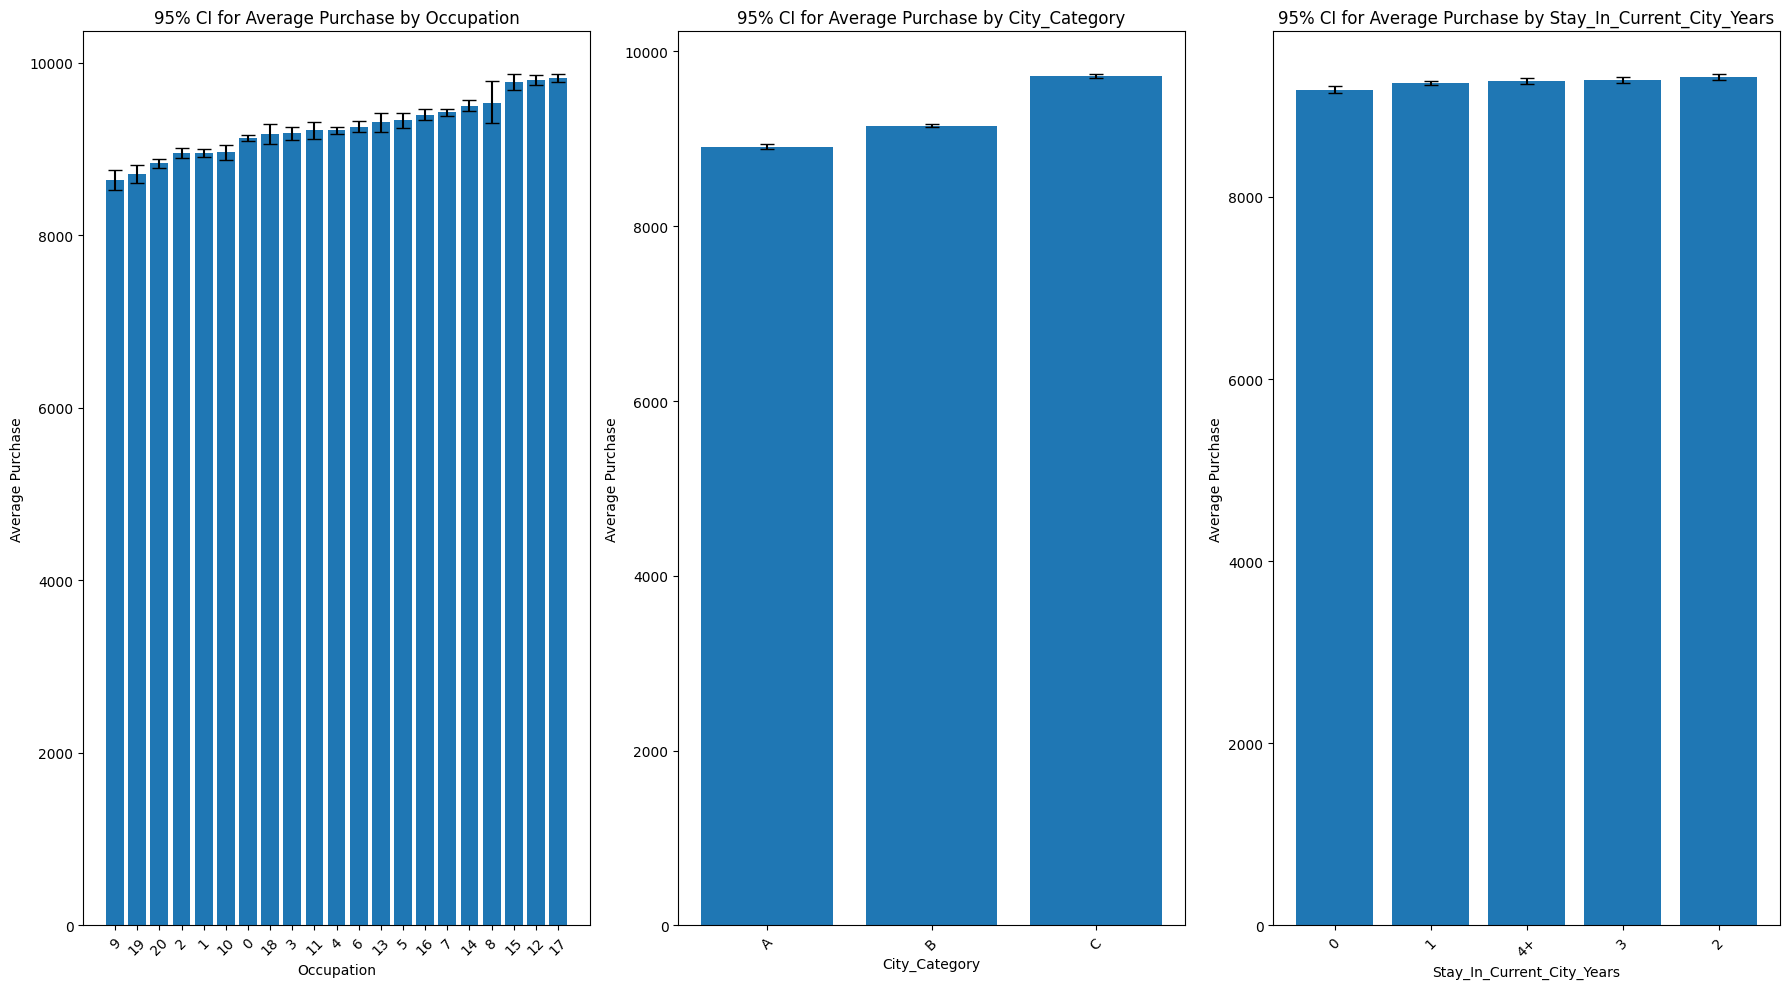

In [131]:
def compute_bootstrap_ci(data, n_bootstrap=1000, ci=95):
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return means, lower, upper

factors = ['Occupation', 'City_Category', 'Stay_In_Current_City_Years']
results = {}

for factor in factors:
    grouped = df_walmart.groupby(factor)['Purchase']
    ci_data = []
    for group, purchases in grouped:
        mean, lower, upper = compute_bootstrap_ci(purchases.values)
        ci_data.append({
            'Group': group,
            'Mean': purchases.mean(),
            'CI Lower': lower,
            'CI Upper': upper
        })
    results[factor] = pd.DataFrame(ci_data)

# Plotting the confidence intervals
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, factor in zip(axes, factors):    
    data = results[factor].sort_values('Mean')
    print(data)
    print()
    ax.bar(data['Group'].astype(str), data['Mean'],
                yerr=[data['Mean'] - data['CI Lower'], data['CI Upper'] - data['Mean']], capsize=5)
     #ax.bar(ci_df['Age'], ci_df['Mean'], yerr=[ci_df['Mean'] - ci_df['Lower'], ci_df['Upper'] - ci_df['Mean']],
      #     capsize=10, color=['skyblue', 'lightgreen'], edgecolor='black')
    ax.set_title(f'95% CI for Average Purchase by {factor}')
    ax.set_xlabel(factor)
    ax.set_ylabel('Average Purchase')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Key Insights:

- **Occupation:** Some occupations clearly spend more than others, suggesting potential for occupation-based targeting.
- **City Category:** Customers in City B and C tend to spend slightly more than those in City A.
- **Stay in Current City:** Spending patterns vary with how long customers have stayed in their current city. Longer-term residents (especially those with 4+ years) show higher average spending.

# Interpretation & Business Implications for Walmart

1. **Age-Specific Spending Patterns**
- 51-55 age group spends significantly more on average.
- 0-17 spends significantly less, likely due to limited purchasing power.
  
2. **Targeted Marketing Opportunities**
- Walmart can design premium product promotions for the 51-55 group.
- Offer budget-friendly bundles or youth-oriented products for the 0-17 group.
  
3. **Personalized Shopping Experience**
- Use age-based insights to personalize recommendations, discounts, and loyalty programs.
4. **Inventory & Merchandising**
- Stock higher-value items in categories popular with older shoppers.
- Focus on trendy, affordable items for younger demographics.

# Strategic Insights & Recommendations for Walmart
### 1. Gender-Based Spending Behavior
   
**Finding:** Males have a significantly higher average purchase amount than females. The 95% confidence intervals for the two groups do not overlap, indicating a statistically significant difference.

**Recommendation:**
- *Targeted Promotions:* Develop premium product campaigns and loyalty programs tailored to male shoppers.
- *Engagement Strategies:* Introduce incentives or personalized offers to encourage higher spending among female customers.
  
### 2. Marital Status Spending Behavior
   
**Finding:** The average spending between married and unmarried individuals is not significantly different. Their confidence intervals overlap, suggesting similar purchasing behavior.
  
**Recommendation:**
- *Unified Campaigns:* Focus marketing efforts on shared interests or product categories rather than marital status.
- *Behavior-Based Segmentation:* Shift from demographic to behavioral segmentation (e.g., Occupation, location wise purchase).
  
### 3. Age Group Spending Patterns
   
**Finding:**
- 51–55 age group spends the most on average, with a distinct confidence interval.
- 0–17 age group spends the least, with no overlap with older groups.
- Several age groups (18–25, 26–35, 46–50, 55+) have overlapping intervals, indicating similar spending.
  
**Recommendation:**
- *High-Value Targeting:* Prioritize high-value campaigns for the 51–55 age group with premium offerings and exclusive deals.
- *Youth Engagement:* Offer budget-friendly, trend-driven products for the 0–17 group, possibly targeting parents or guardians.
- *Age-Specific Bundles:* Create product bundles or experiences tailored to the lifestyle and needs of each age group.
  
### 4. Sample Size & Data Strategy
   
**Finding:** Larger sample sizes yield narrower confidence intervals, improving the precision of insights.
  
**Recommendation:**
- *Invest in Data Collection:* Continue expanding data collection efforts to improve the accuracy of customer insights.
- *Real-Time Analytics:* Implement real-time dashboards to monitor spending trends across demographics.
  
### 5. Occupation-Based Campaigns:
   
**Finding:** Tailor promotions for high-spending occupational groups (e.g., professionals, tech workers).

**Recommendation:**
- *Occupation-Specific Promotions:* Identify high-spending occupations and tailor campaigns (e.g., tech professionals, healthcare workers).
- *Corporate Partnerships:* Collaborate with companies to offer employee-exclusive deals.
  
### 6. City-Specific Strategies:

**Finding:** 
- *For City A:* Introduce incentives to boost spending (e.g., loyalty programs).
- *For City B/C:* Expand product lines that align with their preferences.
- *Localized Engagement:*
- Offer community-based programs or long-term customer rewards for residents with longer city tenure.
- Use geo-targeted ads to engage newer residents with welcome offers.

**Recommendation:**
- *Localized Promotions:* Offer city-specific deals or events to boost engagement in City A.
- *Expand Inventory:* Stock more high-demand items in City B and C based on local preferences.

### 7. Stay Duration in Current City:
   
**Finding:** Customers who have stayed 4+ years in their city spend more on average.

**Recommendation:**
- *Loyalty Recognition:* Reward long-term residents with exclusive offers or early access to sales.
- *Welcome Offers:* Engage newer residents with onboarding discounts or personalized recommendations.
  
# Business Impact Potential
By implementing these recommendations, Walmart can:
- Walmart can optimize marketing ROI through better-targeted campaigns.
- Improve customer satisfaction with personalized experiences.
- Enhance inventory planning and product placement based on demographic trends.
- Enhance customer satisfaction and loyalty.